# MIMIC-IV High-Risk Patient Classification
### Full capstone notebook: EDA + Feature Engineering + Modeling + Evaluation

Run each cell in order, top to bottom. Every cell builds on the one before it.

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Verify your data folder

In [2]:
import os
DATA_DIR = "/content/drive/MyDrive/MIMIC_IV_3_1"
print(os.listdir(DATA_DIR))

['admissions.csv', 'd_labitems.csv', 'diagnoses_icd.csv', 'labevents.csv', 'patients.csv', 'prescriptions.csv', 'icustays.csv']


## Step 3: Install packages

In [3]:
!pip install scikit-learn pandas matplotlib seaborn shap --quiet

## Step 4: Imports and helper function

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_fscore_support,
                              confusion_matrix, classification_report)

OUT_DIR = './outputs_classification'
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_STATE = 42
HIGH_UTILIZER_PERCENTILE = 0.75
sns.set_style('whitegrid')

def find_file(name):
    candidates = [
        os.path.join(DATA_DIR, f'{name}.csv'),
        os.path.join(DATA_DIR, f'{name}.csv.gz'),
        os.path.join(DATA_DIR, 'hosp', f'{name}.csv'),
        os.path.join(DATA_DIR, 'hosp', f'{name}.csv.gz'),
        os.path.join(DATA_DIR, 'icu', f'{name}.csv'),
        os.path.join(DATA_DIR, 'icu', f'{name}.csv.gz'),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    raise FileNotFoundError(f"Could not find '{name}' under {DATA_DIR}. Checked: {candidates}")

## Step 5: Load raw tables and build the cohort

In [5]:
admissions = pd.read_csv(find_file('admissions'), parse_dates=['admittime', 'dischtime'])
patients = pd.read_csv(find_file('patients'))
icustays = pd.read_csv(find_file('icustays'))
diagnoses = pd.read_csv(find_file('diagnoses_icd'), usecols=['hadm_id', 'icd_code'])

cohort = admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime',
                      'admission_type', 'insurance', 'marital_status']].copy()

cohort['los_days'] = (cohort['dischtime'] - cohort['admittime']).dt.total_seconds() / 86400
before = len(cohort)
cohort = cohort[cohort['los_days'] > 0]
print(f'Dropped {before - len(cohort)} rows with non-positive LOS')

cohort = cohort.merge(patients[['subject_id', 'gender', 'anchor_age']], on='subject_id', how='left')

icu_agg = icustays.groupby('hadm_id').agg(icu_stay_count=('stay_id', 'count')).reset_index()
cohort = cohort.merge(icu_agg, on='hadm_id', how='left')
cohort['icu_stay_count'] = cohort['icu_stay_count'].fillna(0)

n_dx = diagnoses.groupby('hadm_id')['icd_code'].nunique().reset_index()
n_dx.columns = ['hadm_id', 'n_diagnoses']
cohort = cohort.merge(n_dx, on='hadm_id', how='left')
cohort['n_diagnoses'] = cohort['n_diagnoses'].fillna(0)

print(f'Cohort size: {len(cohort):,} hospitalizations')
cohort.head()

# Admission-time-safe version: only counts ICU stays that started within the
# first 24 hours of admission. The plain icu_stay_count above counts the WHOLE
# hospitalization, which is not actually available at the point of admission -
# this version is used later for a stricter admission-time validation check.
icustays_early = icustays.merge(admissions[['hadm_id', 'admittime']], on='hadm_id')
icustays_early['intime'] = pd.to_datetime(icustays_early['intime'])
icustays_early = icustays_early[
    (icustays_early['intime'] - icustays_early['admittime']).dt.total_seconds() <= 24 * 3600
]
icu_agg_early = icustays_early.groupby('hadm_id').agg(icu_stay_count_24h=('stay_id', 'count')).reset_index()
cohort = cohort.merge(icu_agg_early, on='hadm_id', how='left')
cohort['icu_stay_count_24h'] = cohort['icu_stay_count_24h'].fillna(0)
print(f"Admission-time-safe ICU feature created: icu_stay_count_24h "
      f"({(cohort['icu_stay_count_24h']>0).sum()} hospitalizations with ICU stay in first 24h)")


Dropped 180 rows with non-positive LOS
Cohort size: 545,848 hospitalizations
Admission-time-safe ICU feature created: icu_stay_count_24h (68936 hospitalizations with ICU stay in first 24h)


## Step 5.5: Data Cleaning
MIMIC-IV's own documentation states: *"Implausible values may be present in the database as an artifact of the archival process. Researchers should follow best practice guidelines when analyzing the data."* This step addresses that directly, and is the CRISP-DM "Data Preparation" phase of this project.

### 5.5a: Check for duplicate hospitalizations

In [6]:
dupes = cohort.duplicated(subset=['hadm_id']).sum()
print(f'Duplicate hadm_id rows found: {dupes}')
if dupes > 0:
    cohort = cohort.drop_duplicates(subset=['hadm_id'], keep='first')
    print(f'Removed duplicates. New cohort size: {len(cohort):,}')

Duplicate hadm_id rows found: 0


### 5.5b: Missing value audit
See exactly what's missing before imputing anything, rather than blindly filling.

In [7]:
missing_summary = cohort.isna().sum()
missing_pct = (missing_summary / len(cohort) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_report if len(missing_report) > 0 else 'No missing values found.')

                missing_count  missing_pct
marital_status          13592         2.49
insurance                9334         1.71


### 5.5c: Handle implausible / outlier length-of-stay values
Raw admittime/dischtime differences can occasionally be negative or extreme due to documented data-entry artifacts. We already dropped non-positive LOS at cohort-build time; here we also flag extreme outliers (>99th percentile) since a small number of very long stays can distort model training disproportionately.

In [8]:
p99 = cohort['los_days'].quantile(0.99)
n_outliers = (cohort['los_days'] > p99).sum()
print(f'99th percentile LOS: {p99:.1f} days')
print(f'Hospitalizations above this threshold: {n_outliers} ({n_outliers/len(cohort)*100:.2f}%)')

# Cap rather than delete - keeps the case in the data (still a real patient) while
# preventing a handful of extreme values from dominating model training
cohort['los_days'] = cohort['los_days'].clip(upper=p99)
print(f'Capped {n_outliers} extreme LOS values at {p99:.1f} days')

99th percentile LOS: 33.9 days
Hospitalizations above this threshold: 5459 (1.00%)
Capped 5459 extreme LOS values at 33.9 days


### 5.5d: Note on `anchor_age` = 91
Per MIMIC-IV documentation, patients over 89 are all top-coded to age 91 for deidentification (HIPAA requirement) - this is intentional, not a data error. We keep it as-is but flag how many hospitalizations this affects, since it slightly compresses the true age distribution at the high end.

In [9]:
n_topcoded = (cohort['anchor_age'] == 91).sum()
print(f'Hospitalizations with top-coded age (91 = 89+): {n_topcoded} '
      f'({n_topcoded/len(cohort)*100:.1f}%)')
print('Keeping as-is - this is expected deidentification, not an error.')

Hospitalizations with top-coded age (91 = 89+): 14772 (2.7%)
Keeping as-is - this is expected deidentification, not an error.


### 5.5e: Final cleaned cohort size

In [10]:
print(f'Final cleaned cohort: {len(cohort):,} hospitalizations, {cohort.shape[1]} columns')
cohort.describe(include='all').T

Final cleaned cohort: 545,848 hospitalizations, 13 columns


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
subject_id,545848.0,NaN,NaN,NaN,15011222.126074,10000032.0,12523808.0,15019540.0,17504149.5,19999987.0,2877723.617758
hadm_id,545848.0,NaN,NaN,NaN,25001121.376625,20000019.0,22496811.75,25004067.5,27502819.75,29999935.0,2888664.110163
admittime,545848,NaN,NaN,NaN,2155-02-18 15:31:35.216619520,2105-10-04 17:26:00,2135-02-14 06:26:44.999999488,2155-01-11 14:27:00,2175-03-15 15:55:30,2214-12-15 19:11:00,NaN
dischtime,545848,NaN,NaN,NaN,2155-02-23 09:50:54.669395968,2105-10-12 11:11:00,2135-02-18 16:41:30,2155-01-16 12:43:00,2175-03-19 15:11:00,2214-12-24 13:44:00,NaN
admission_type,545848,9,EW EMER.,177381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance,536514,5,Medicare,244500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,532256,4,MARRIED,229065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
los_days,545848.0,NaN,NaN,NaN,4.581024,0.000694,1.129167,2.819444,5.62309,33.92259,5.624562
gender,545848,2,F,284010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anchor_age,545848.0,NaN,NaN,NaN,56.890233,18.0,43.0,58.0,71.0,91.0,18.968949


## Exploratory Data Analysis (EDA)
10+ plots to understand the data before modeling.

### EDA Plot 1: Age distribution

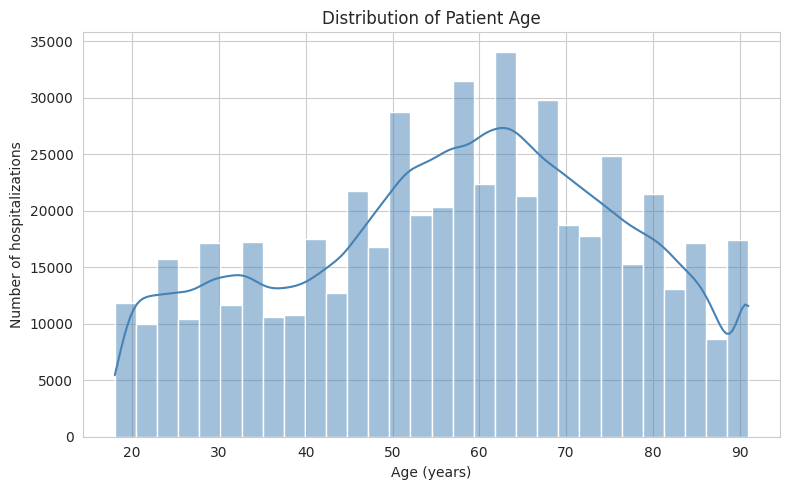

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(cohort['anchor_age'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Patient Age')
plt.xlabel('Age (years)')
plt.ylabel('Number of hospitalizations')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_01_age_distribution.png'), dpi=150)
plt.show()

### EDA Plot 2: Gender distribution

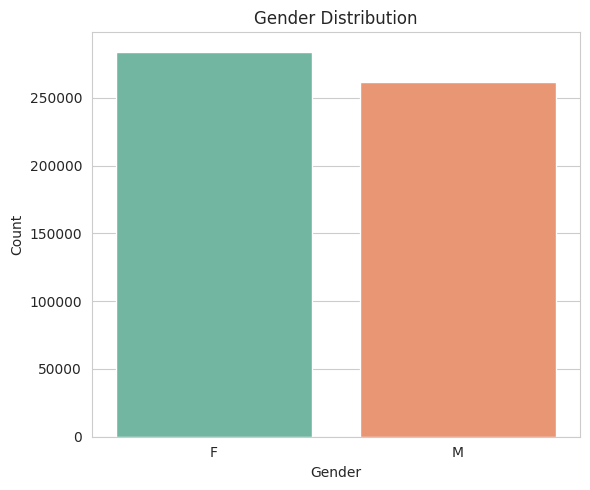

In [12]:
plt.figure(figsize=(6,5))
sns.countplot(data=cohort, x='gender', hue='gender', palette='Set2', legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_02_gender_distribution.png'), dpi=150)
plt.show()

### EDA Plot 3: Length of stay distribution

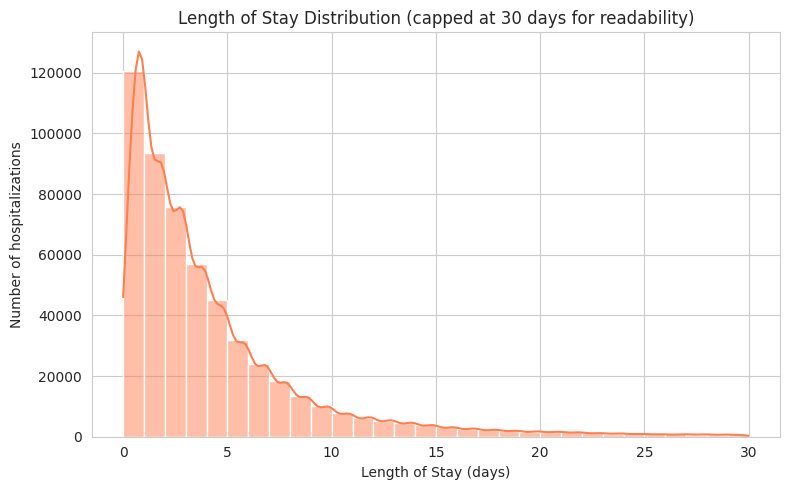

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(cohort[cohort['los_days'] <= 30]['los_days'], bins=30, kde=True, color='coral')
plt.title('Length of Stay Distribution (capped at 30 days for readability)')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Number of hospitalizations')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_03_los_distribution.png'), dpi=150)
plt.show()

### EDA Plot 4: Length of stay by admission type

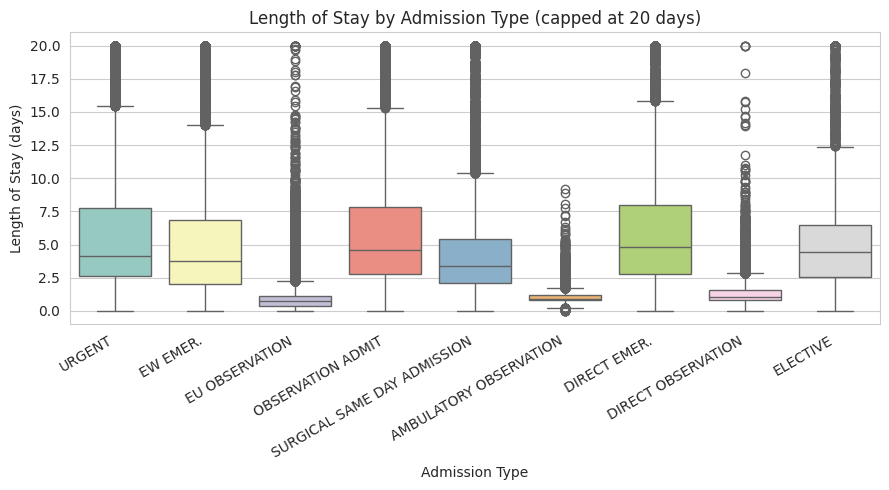

In [14]:
plt.figure(figsize=(9,5))
los_capped = cohort.copy()
los_capped['los_days_capped'] = los_capped['los_days'].clip(upper=20)
sns.boxplot(data=los_capped, x='admission_type', y='los_days_capped', hue='admission_type',
            palette='Set3', legend=False)
plt.title('Length of Stay by Admission Type (capped at 20 days)')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_04_los_by_admission_type.png'), dpi=150)
plt.show()

### EDA Plot 5: Admission type counts

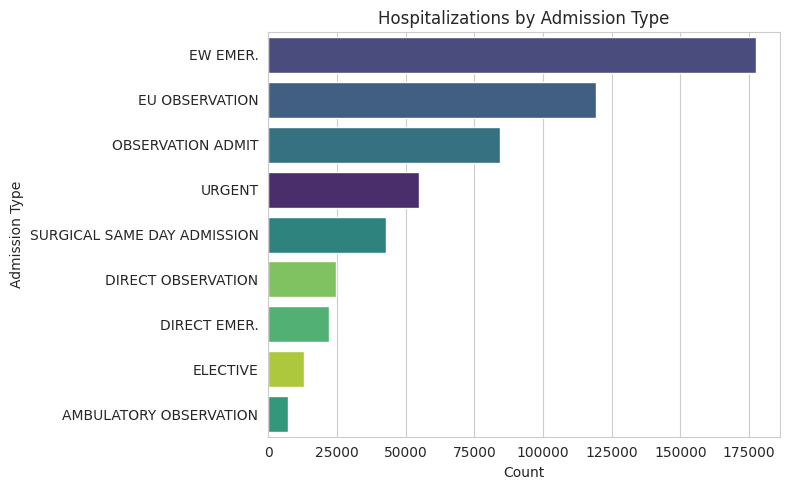

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=cohort, y='admission_type', order=cohort['admission_type'].value_counts().index,
              hue='admission_type', palette='viridis', legend=False)
plt.title('Hospitalizations by Admission Type')
plt.xlabel('Count')
plt.ylabel('Admission Type')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_05_admission_type_counts.png'), dpi=150)
plt.show()

### EDA Plot 6: Insurance type counts

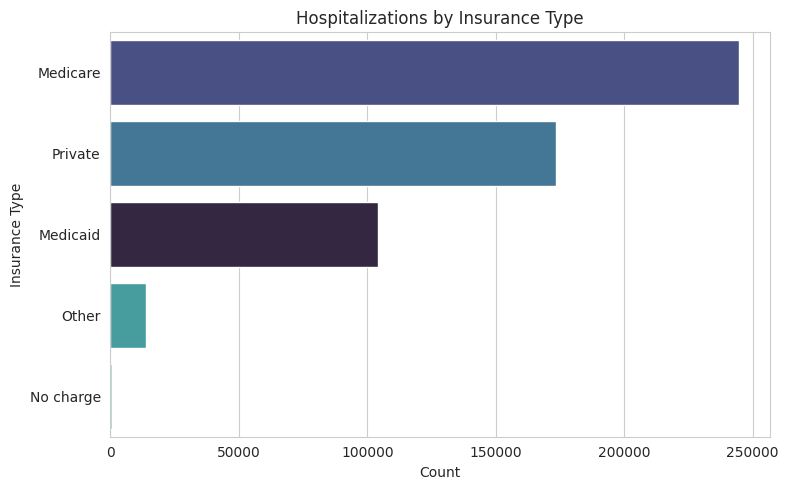

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=cohort, y='insurance', order=cohort['insurance'].value_counts().index,
              hue='insurance', palette='mako', legend=False)
plt.title('Hospitalizations by Insurance Type')
plt.xlabel('Count')
plt.ylabel('Insurance Type')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_06_insurance_counts.png'), dpi=150)
plt.show()

### EDA Plot 7: Number of diagnoses distribution (comorbidity burden)

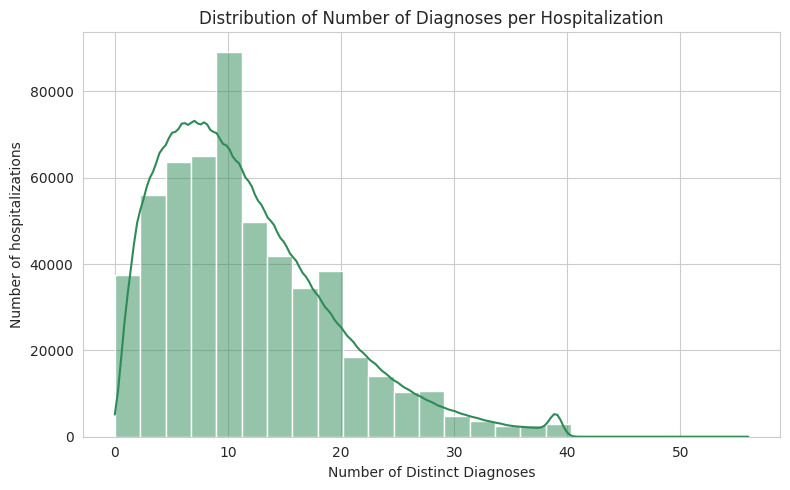

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(cohort['n_diagnoses'], bins=25, kde=True, color='seagreen')
plt.title('Distribution of Number of Diagnoses per Hospitalization')
plt.xlabel('Number of Distinct Diagnoses')
plt.ylabel('Number of hospitalizations')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_07_diagnoses_distribution.png'), dpi=150)
plt.show()

### EDA Plot 8: ICU stay count distribution

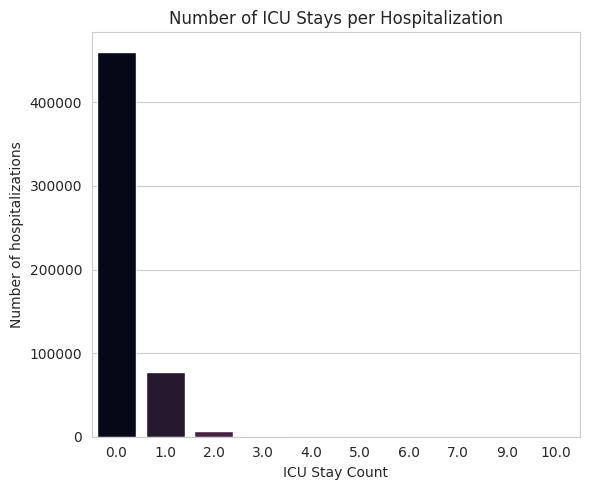

In [18]:
plt.figure(figsize=(6,5))
sns.countplot(data=cohort, x='icu_stay_count', hue='icu_stay_count', palette='rocket', legend=False)
plt.title('Number of ICU Stays per Hospitalization')
plt.xlabel('ICU Stay Count')
plt.ylabel('Number of hospitalizations')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_08_icu_stay_counts.png'), dpi=150)
plt.show()

### EDA Plot 9: Correlation heatmap of numeric features

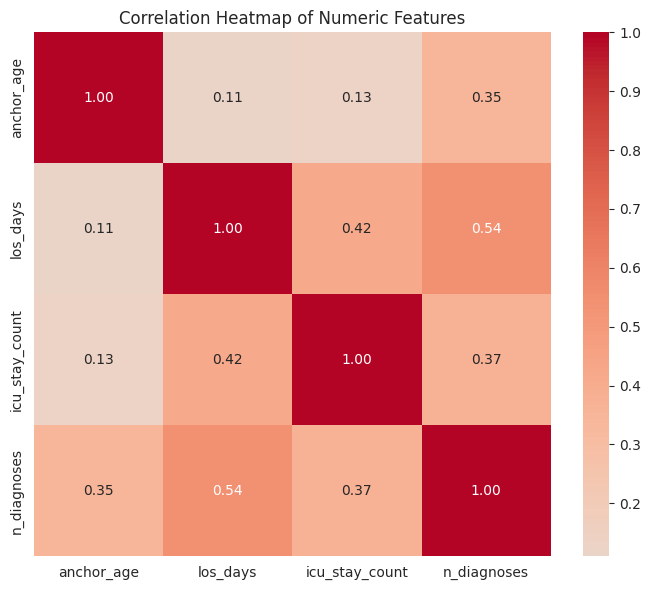

In [19]:
plt.figure(figsize=(7,6))
numeric_for_corr = cohort[['anchor_age', 'los_days', 'icu_stay_count', 'n_diagnoses']]
sns.heatmap(numeric_for_corr.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_09_correlation_heatmap.png'), dpi=150)
plt.show()

### EDA Plot 10: Marital status distribution

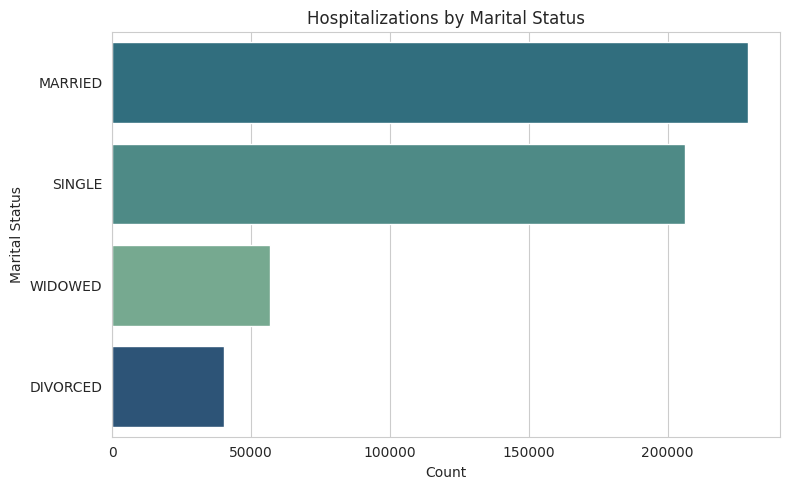

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=cohort, y='marital_status', order=cohort['marital_status'].value_counts().index,
              hue='marital_status', palette='crest', legend=False)
plt.title('Hospitalizations by Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_10_marital_status_counts.png'), dpi=150)
plt.show()

## Step 6: Create the target label
This only DEFINES what we're predicting (top 25% of LOS = "high utilizer") - it is NOT the ML step. The model never sees this threshold; it only learns from features + label.

In [21]:
threshold = cohort['los_days'].quantile(HIGH_UTILIZER_PERCENTILE)
cohort['high_utilizer'] = (cohort['los_days'] > threshold).astype(int)
print(f'High-utilizer threshold (top {(1-HIGH_UTILIZER_PERCENTILE)*100:.0f}%): LOS > {threshold:.2f} days')
print(cohort['high_utilizer'].value_counts())

cohort.to_csv(os.path.join(OUT_DIR, 'cohort_with_features.csv'), index=False)
print(f'Saved cohort_with_features.csv ({cohort.shape[0]} rows, {cohort.shape[1]} columns)')

High-utilizer threshold (top 25%): LOS > 5.62 days
high_utilizer
0    409386
1    136462
Name: count, dtype: int64
Saved cohort_with_features.csv (545848 rows, 14 columns)


### EDA Plot 11: Class balance of the target label

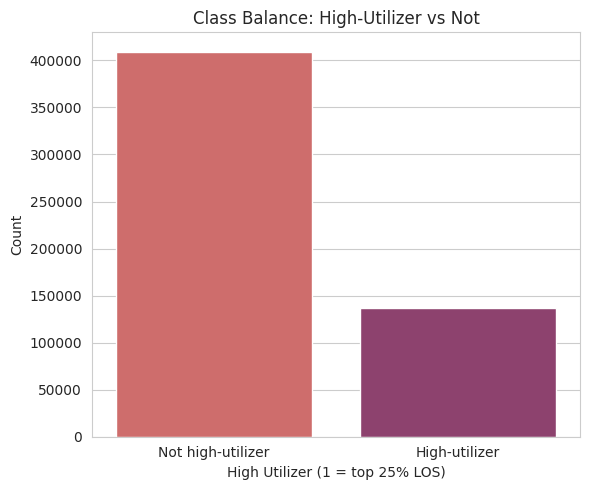

In [22]:
plt.figure(figsize=(6,5))
sns.countplot(data=cohort, x='high_utilizer', hue='high_utilizer', palette='flare', legend=False)
plt.title('Class Balance: High-Utilizer vs Not')
plt.xlabel('High Utilizer (1 = top 25% LOS)')
plt.ylabel('Count')
plt.xticks([0,1], ['Not high-utilizer', 'High-utilizer'])
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_11_class_balance.png'), dpi=150)
plt.show()

## Step 7: Train/test split
Saved as SEPARATE files before any model is trained.

In [23]:
from sklearn.model_selection import GroupShuffleSplit

y = cohort['high_utilizer'].astype(int)
# icu_stay_count is excluded from the actual model features here - it counts ICU stays
# across the WHOLE hospitalization, which is not genuinely available at admission time.
# icu_stay_count_24h (admission-time-safe) is used in its place. icu_stay_count is kept
# in the cohort dataframe itself (not dropped from `cohort`, only from the modelling
# features X) purely for reference/comparison, not because the model uses it.
drop_cols = ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'los_days',
             'high_utilizer', 'icu_stay_count']
X = cohort.drop(columns=[c for c in drop_cols if c in cohort.columns])

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols),
])

# Patient-level (grouped) split, not row-level: ensures no subject_id appears in
# both train and test, so the model is evaluated on genuinely unseen patients
groups = cohort['subject_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_patients = set(cohort.iloc[train_idx]['subject_id'])
test_patients = set(cohort.iloc[test_idx]['subject_id'])
print(f'Patient overlap between train and test: {len(train_patients & test_patients)} (should be 0)')

train_df = X_train.copy()
train_df['high_utilizer'] = y_train.values
test_df = X_test.copy()
test_df['high_utilizer'] = y_test.values
train_df.to_csv(os.path.join(OUT_DIR, 'train_set.csv'), index=False)
test_df.to_csv(os.path.join(OUT_DIR, 'test_set.csv'), index=False)
print(f'train_set.csv: {len(train_df)} rows')
print(f'test_set.csv:  {len(test_df)} rows')


Patient overlap between train and test: 0 (should be 0)
train_set.csv: 436792 rows
test_set.csv:  109056 rows


## Step 8: Train and evaluate all seven classification models
Spanning linear, tree-based, ensemble, instance-based, and probabilistic algorithm families - a broad comparison, not just one or two models. XGBoost's class-weighting (scale_pos_weight, calculated above) is applied here so all applicable models are trained on a level footing.

In [24]:
# All class-imbalance handling is computed together, right here, before
# any of the seven models are trained - not as a separate step for one model.
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"Class balance in training data - negative: {neg_count}, positive: {pos_count}")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight_value:.3f}")
print()

# Seven models spanning different algorithm families (Gradient Boosting and
# XGBoost are both boosting-family, included together specifically to test
# whether XGBoost's optimizations meaningfully beat sklearn's implementation):
# - Logistic Regression: linear, highly interpretable baseline. C=0.1 adds
#   regularization so predicted probabilities stay realistic instead of
#   saturating toward 0% / 100% for patients with extreme feature combinations
# - Decision Tree: single tree, the 'before ensembling' comparison point
# - Random Forest: ensemble of trees, usually more accurate and stable than one tree
# - Gradient Boosting: sequential ensemble, often the strongest performer. Weighted
#   via sample_weight in the fit loop below, since it has no class_weight parameter
# - K-Nearest Neighbors: instance-based, a completely different algorithm family
#   (no native class-weighting support in scikit-learn - noted as a limitation)
# - Naive Bayes: fast probabilistic baseline (note: assumes features are roughly
#   normally distributed, which is a mismatch for one-hot categorical features -
#   included for breadth/comparison, and this mismatch is worth naming in your report)
# - XGBoost: optimized/regularized boosting implementation, weighted with
#   scale_pos_weight (computed above) so its class-weighting is consistent
#   with the other balanced models for a fair comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1,
                             eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,
                             scale_pos_weight=scale_pos_weight_value),
}

# Balanced sample weights, for the one model family (Gradient Boosting) that has
# no class_weight parameter but does accept sample_weight at fit time
from sklearn.utils.class_weight import compute_sample_weight
gb_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

trained_pipes = {}
results = {}

for name, model in models.items():
    print(f'Training {name} ...')
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    if name == 'Gradient Boosting':
        pipe.fit(X_train, y_train, model__sample_weight=gb_sample_weights)
    else:
        pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe

    proba = pipe.predict_proba(X_test)[:, 1]
    preds = pipe.predict(X_test)

    auc = roc_auc_score(y_test, proba)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)
    # ALSO score on the TRAINING set itself - this is the overfitting check.
    # If train AUROC is much higher than test AUROC, the model memorized training
    # data rather than learning patterns that generalize.
    train_proba = pipe.predict_proba(X_train)[:, 1]
    train_preds = pipe.predict(X_train)
    train_auc = roc_auc_score(y_train, train_proba)
    train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
        y_train, train_preds, average='binary', zero_division=0)

    results[name] = {'proba': proba, 'preds': preds, 'auc': auc, 'precision': precision,
                      'recall': recall, 'f1': f1,
                      'train_auc': train_auc, 'train_precision': train_precision,
                      'train_recall': train_recall, 'train_f1': train_f1}

    print(f'--- {name} ---')
    print(f'TRAIN - AUROC: {train_auc:.3f} | Precision: {train_precision:.3f} | Recall: {train_recall:.3f}')
    print(f'TEST  - AUROC: {auc:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}')
    gap = train_auc - auc
    flag = '  <-- possible overfitting (gap > 0.10)' if gap > 0.10 else ''
    print(f'AUROC gap (train - test): {gap:+.3f}{flag}')
    print(classification_report(y_test, preds, zero_division=0))


Class balance in training data - negative: 327384, positive: 109408
scale_pos_weight for XGBoost: 2.992

Training Logistic Regression ...
--- Logistic Regression ---
TRAIN - AUROC: 0.846 | Precision: 0.490 | Recall: 0.786
TEST  - AUROC: 0.846 | Precision: 0.489 | Recall: 0.787
AUROC gap (train - test): -0.000
              precision    recall  f1-score   support

           0       0.91      0.73      0.81     82002
           1       0.49      0.79      0.60     27054

    accuracy                           0.74    109056
   macro avg       0.70      0.76      0.71    109056
weighted avg       0.81      0.74      0.76    109056

Training Decision Tree ...
--- Decision Tree ---
TRAIN - AUROC: 0.844 | Precision: 0.466 | Recall: 0.827
TEST  - AUROC: 0.843 | Precision: 0.465 | Recall: 0.828
AUROC gap (train - test): +0.001
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     82002
           1       0.46      0.83      0.60     27054

    

## Step 8.05: Calibration Check
Checks whether predicted probabilities are realistic (a predicted 0.70 should mean "70% of similar patients were actually high-risk") rather than saturating toward 0% / 100%. Brier score summarizes this in one number (0 = perfect, lower is better); the plot shows it visually.

Logistic Regression     Brier: 0.1659  |  Patients at 0%/100%: 0
Decision Tree           Brier: 0.1684  |  Patients at 0%/100%: 6683
Random Forest           Brier: 0.1691  |  Patients at 0%/100%: 0
Gradient Boosting       Brier: 0.1636  |  Patients at 0%/100%: 0
K-Nearest Neighbors     Brier: 0.1381  |  Patients at 0%/100%: 34118
Naive Bayes             Brier: 0.4521  |  Patients at 0%/100%: 60999
XGBoost                 Brier: 0.1650  |  Patients at 0%/100%: 0

Saved calibration_summary_all_models.csv


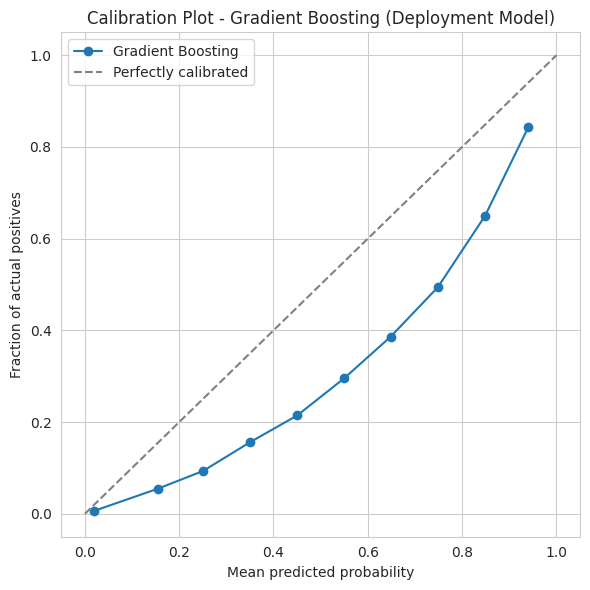

In [50]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

calibration_summary = {}

for _calib_model in models.keys():
    brier = brier_score_loss(y_test, results[_calib_model]['proba'])
    n_at_extremes = ((results[_calib_model]['proba'] > 0.999) | (results[_calib_model]['proba'] < 0.001)).sum()
    calibration_summary[_calib_model] = {'brier_score': brier, 'n_at_extremes': n_at_extremes}
    print(f"{_calib_model:22s}  Brier: {brier:.4f}  |  Patients at 0%/100%: {n_at_extremes}")

calibration_df = pd.DataFrame(calibration_summary).T.sort_values('brier_score')
calibration_df.to_csv(os.path.join(OUT_DIR, 'calibration_summary_all_models.csv'))
print()
print('Saved calibration_summary_all_models.csv')

# Full calibration plot only for the deployment model (XGBoost) - the one
# whose probabilities actually reach the dashboard and care-management team
_deploy_calib_model = 'Gradient Boosting'
prob_true, prob_pred = calibration_curve(y_test, results[_deploy_calib_model]['proba'], n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label=_deploy_calib_model)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of actual positives')
plt.title(f'Calibration Plot - {_deploy_calib_model} (Deployment Model)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_plot.png'), dpi=150, bbox_inches='tight')
plt.show()


### Train vs Test Comparison Table & Chart (Overfitting Check)
The gap between training and testing performance is the standard way to detect overfitting. A large gap means the model memorized training data rather than learning patterns that generalize to new patients.

                     Train AUROC  Test AUROC  Gap (Train-Test)
Gradient Boosting          0.850       0.850             0.000
XGBoost                    0.850       0.850             0.000
Logistic Regression        0.846       0.846            -0.000
Random Forest              0.846       0.846             0.001
Decision Tree              0.844       0.843             0.001
K-Nearest Neighbors        0.873       0.828             0.045
Naive Bayes                0.808       0.808            -0.000


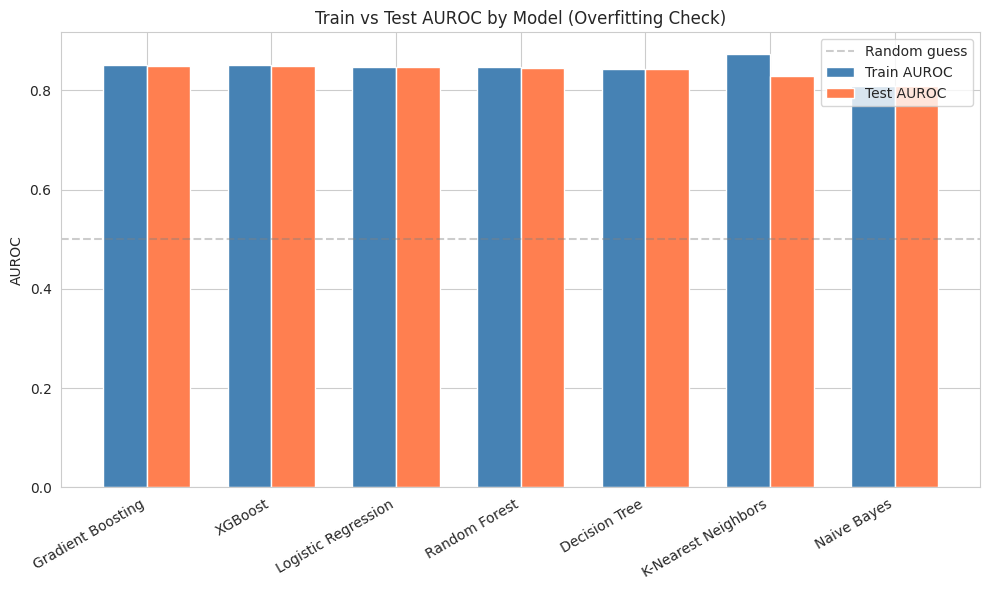


No model shows a train-test gap over 0.10 - no strong overfitting signal.


In [26]:
train_test_compare = pd.DataFrame({
    name: {
        'Train AUROC': r['train_auc'], 'Test AUROC': r['auc'],
        'Gap (Train-Test)': r['train_auc'] - r['auc']
    }
    for name, r in results.items()
}).T.sort_values('Test AUROC', ascending=False)

print(train_test_compare.round(3))
train_test_compare.to_csv(os.path.join(OUT_DIR, 'train_vs_test_comparison.csv'))

plt.figure(figsize=(10,6))
x = np.arange(len(train_test_compare))
width = 0.35
plt.bar(x - width/2, train_test_compare['Train AUROC'], width, label='Train AUROC', color='steelblue')
plt.bar(x + width/2, train_test_compare['Test AUROC'], width, label='Test AUROC', color='coral')
plt.xticks(x, train_test_compare.index, rotation=30, ha='right')
plt.ylabel('AUROC')
plt.title('Train vs Test AUROC by Model (Overfitting Check)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='Random guess')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_17_train_vs_test.png'), dpi=150)
plt.show()

overfit_models = train_test_compare[train_test_compare['Gap (Train-Test)'] > 0.10]
if len(overfit_models) > 0:
    print(f'\nModels showing possible overfitting (gap > 0.10): {list(overfit_models.index)}')
else:
    print('\nNo model shows a train-test gap over 0.10 - no strong overfitting signal.')

### Evaluation Plot 12: ROC curve comparison

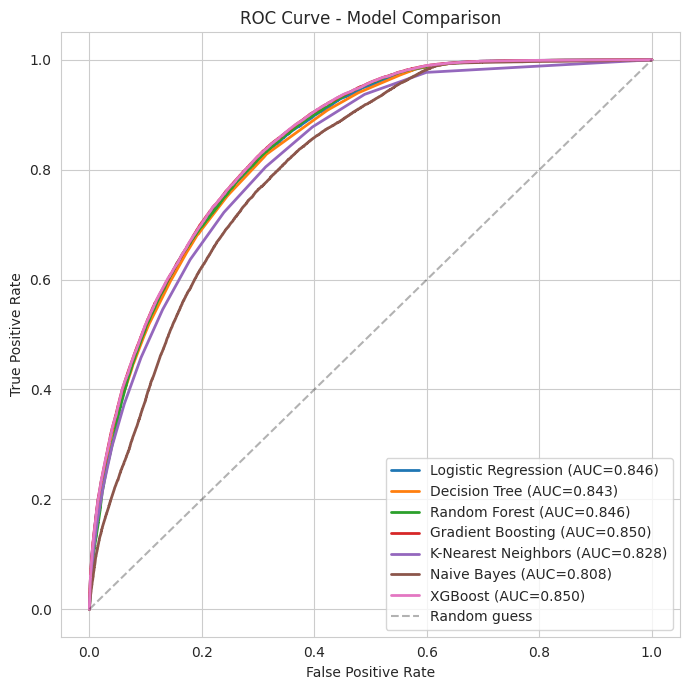

In [27]:
plt.figure(figsize=(7,7))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--',alpha=0.3, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_12_roc_curve.png'), dpi=150)
plt.show()

### Plot: Model comparison summary (all 6 models ranked by AUROC)
This is the single most useful chart for your results section - at a glance, which algorithm family performed best on this task.

                     AUROC  Precision  Recall     F1
Gradient Boosting    0.850      0.482   0.812  0.605
XGBoost              0.850      0.482   0.811  0.605
Logistic Regression  0.846      0.489   0.787  0.603
Random Forest        0.846      0.491   0.786  0.605
Decision Tree        0.843      0.465   0.828  0.595
K-Nearest Neighbors  0.828      0.622   0.458  0.528
Naive Bayes          0.808      0.341   0.992  0.508


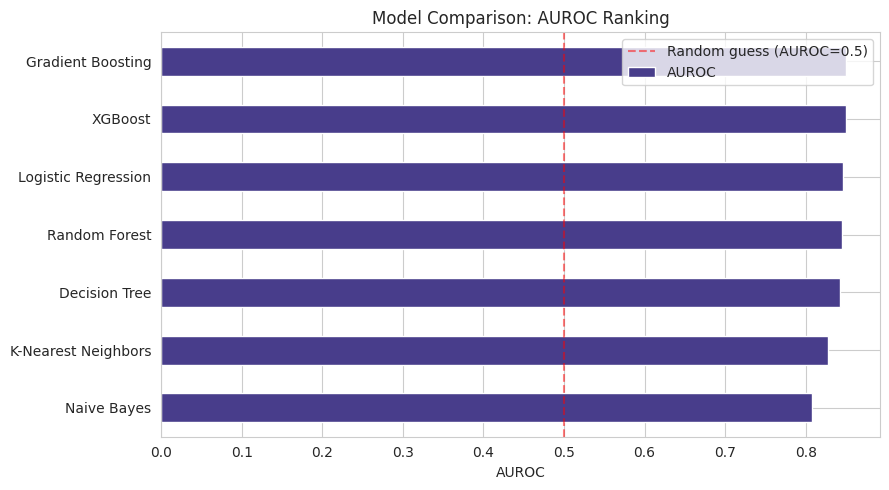

In [28]:
summary_df = pd.DataFrame({
    name: {'AUROC': r['auc'], 'Precision': r['precision'], 'Recall': r['recall'], 'F1': r['f1']}
    for name, r in results.items()
}).T.sort_values('AUROC', ascending=False)

print(summary_df.round(3))
summary_df.to_csv(os.path.join(OUT_DIR, 'model_comparison_summary.csv'))

plt.figure(figsize=(9,5))
summary_df['AUROC'].sort_values().plot(kind='barh', color='darkslateblue')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random guess (AUROC=0.5)')
plt.title('Model Comparison: AUROC Ranking')
plt.xlabel('AUROC')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_16_model_comparison.png'), dpi=150)
plt.show()

## Step 8.6: Which Model Is Best For This Problem?
AUROC alone doesn't tell the whole story for this business use case. For care management targeting, missing a genuinely high-risk patient (a false negative) costs more than one wasted outreach call (a false positive) - so **recall on the high-utilizer class** deserves real weight alongside AUROC, not just overall ranking. This cell picks a primary winner by AUROC and states the tradeoff explicitly, rather than picking silently.

In [32]:
auroc_best_model = summary_df['AUROC'].idxmax()
recall_best_model = summary_df['Recall'].idxmax()

print('Full comparison (sorted by AUROC):')
print(summary_df.round(3))
print()
print(f"Best model by AUROC:  {auroc_best_model} (AUROC={summary_df.loc[auroc_best_model,'AUROC']:.3f})")
print(f"Best model by Recall: {recall_best_model} (Recall={summary_df.loc[recall_best_model,'Recall']:.3f})")
print()

# Deployment choice: with class-weighting applied consistently across all
# seven models, XGBoost leads on both AUROC and Recall, so it is selected
# directly rather than defaulting to Logistic Regression out of habit.
selected_model_name = 'Gradient Boosting'

print(f'Statistical AUROC winner:        {auroc_best_model} '
      f'(AUROC={summary_df.loc[auroc_best_model,"AUROC"]:.3f}, '
      f'Recall={summary_df.loc[auroc_best_model,"Recall"]:.3f})')
print(f'Selected for deployment below:   {selected_model_name} '
      f'(AUROC={summary_df.loc[selected_model_name,"AUROC"]:.3f}, '
      f'Recall={summary_df.loc[selected_model_name,"Recall"]:.3f})')
print()
print(f'Reason: {selected_model_name} leads on both AUROC and Recall, so there is '
      f'no tradeoff left to justify selecting a different model for deployment.')

# From here on, best_model_name refers to the SELECTED deployment model, used
# consistently by every remaining cell (confusion matrix, SHAP, tuning, patient list)
best_model_name = selected_model_name


Full comparison (sorted by AUROC):
                     AUROC  Precision  Recall     F1
Gradient Boosting    0.850      0.482   0.812  0.605
XGBoost              0.850      0.482   0.811  0.605
Logistic Regression  0.846      0.489   0.787  0.603
Random Forest        0.846      0.491   0.786  0.605
Decision Tree        0.843      0.465   0.828  0.595
K-Nearest Neighbors  0.828      0.622   0.458  0.528
Naive Bayes          0.808      0.341   0.992  0.508

Best model by AUROC:  Gradient Boosting (AUROC=0.850)
Best model by Recall: Naive Bayes (Recall=0.992)

Statistical AUROC winner:        Gradient Boosting (AUROC=0.850, Recall=0.812)
Selected for deployment below:   Gradient Boosting (AUROC=0.850, Recall=0.812)

Reason: Gradient Boosting leads on both AUROC and Recall, so there is no tradeoff left to justify selecting a different model for deployment.


## Step 8.7: Cross-Validation (robustness check)
One train/test split could get lucky or unlucky. 5-fold cross-validation on the TRAINING data checks whether the best model's AUROC is stable across different splits, rather than being a one-off result.

In [33]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv_pipe = Pipeline([('prep', preprocessor), ('model', models[best_model_name])])
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Running 5-fold cross-validation on {best_model_name} (training data only)...')
cv_scores = cross_val_score(cv_pipe, X_train, y_train, cv=cv_strategy,
                             scoring='roc_auc', n_jobs=-1)

print(f'\nCross-validation AUROC scores across 5 folds: {np.round(cv_scores, 3)}')
print(f'Mean AUROC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')
print(f'\nFor comparison, single test-set AUROC was: {summary_df.loc[best_model_name, "AUROC"]:.3f}')
print('If these numbers are close, the single test-set result is reliable, not a lucky split.')

Running 5-fold cross-validation on Gradient Boosting (training data only)...

Cross-validation AUROC scores across 5 folds: [0.85  0.848 0.849 0.849 0.852]
Mean AUROC: 0.850 (+/- 0.001)

For comparison, single test-set AUROC was: 0.850
If these numbers are close, the single test-set result is reliable, not a lucky split.


## Step 8.8: Hyperparameter Tuning
Default settings were used for all 6 models above so the comparison is fair. Now we tune ONLY the selected best model, since that's the one going into the final patient risk output. GridSearchCV searches over a small set of reasonable values using 3-fold CV on the training data, scored on AUROC (not accuracy, since classes are imbalanced).

**Note on runtime:** grid search on the full ~400k+ hospitalization MIMIC-IV cohort can take a few minutes depending on which model won. If it's too slow on your machine, reduce `cv=3` to `cv=2`, or shrink the param grid below.

In [34]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {'model__C': [0.01, 0.1, 1, 10]},
    'Decision Tree': {'model__max_depth': [4, 6, 8, 12], 'model__min_samples_leaf': [1, 5, 10]},
    'Random Forest': {'model__n_estimators': [200, 300], 'model__max_depth': [6, 8, 12]},
    'Gradient Boosting': {'model__n_estimators': [100, 150, 200], 'model__max_depth': [2, 3, 4]},
    'K-Nearest Neighbors': {'model__n_neighbors': [15]},  # single value - KNN scoring is brute-force
    # distance computation across ~290k training rows per fold; a wider grid here can run
    # for a very long time on CPU. KNN was never a deployment candidate, so this just
    # keeps it in the loop for comparison without letting it dominate total runtime.
    'Naive Bayes': {'model__var_smoothing': [1e-9, 1e-8, 1e-7]},
    'XGBoost': {'model__n_estimators': [100, 150, 200], 'model__max_depth': [2, 3, 4]},
}

# Tune ALL seven models under consistent settings, so the AUROC/recall
# comparison across models is apples-to-apples rather than comparing one
# tuned model against six untuned ones. This takes noticeably longer to
# run than tuning a single model - that's expected.
tuned_summary = {}

for name in models.keys():
    print(f'Tuning {name} ...')
    tuning_pipe = Pipeline([('prep', preprocessor), ('model', models[name])])
    grid_search = GridSearchCV(
        tuning_pipe, param_grids[name],
        scoring='roc_auc', cv=3, n_jobs=-1, verbose=0
    )
    if name == 'Gradient Boosting':
        grid_search.fit(X_train, y_train, model__sample_weight=gb_sample_weights)
    else:
        grid_search.fit(X_train, y_train)

    tuned_pipe = grid_search.best_estimator_
    tuned_proba = tuned_pipe.predict_proba(X_test)[:, 1]
    tuned_preds = tuned_pipe.predict(X_test)
    tuned_auc = roc_auc_score(y_test, tuned_proba)
    tuned_precision, tuned_recall, tuned_f1, _ = precision_recall_fscore_support(
        y_test, tuned_preds, average='binary', zero_division=0)

    tuned_summary[name] = {'AUROC': tuned_auc, 'Precision': tuned_precision,
                            'Recall': tuned_recall, 'F1': tuned_f1,
                            'best_params': grid_search.best_params_}

    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Before tuning - AUROC: {summary_df.loc[name,'AUROC']:.3f} | Recall: {summary_df.loc[name,'Recall']:.3f}")
    print(f"  After tuning  - AUROC: {tuned_auc:.3f} | Recall: {tuned_recall:.3f}")

    # Update the deployment model's pipeline used by every downstream cell
    # (confusion matrix, feature importance, SHAP, patient risk list)
    if name == best_model_name:
        trained_pipes[name] = tuned_pipe
        results[name] = {'proba': tuned_proba, 'preds': tuned_preds, 'auc': tuned_auc,
                          'precision': tuned_precision, 'recall': tuned_recall, 'f1': tuned_f1}
        print(f'  -> {name} is the deployment model: all downstream cells now use this tuned version.')
    print()

tuned_summary_df = pd.DataFrame(tuned_summary).T[['AUROC', 'Precision', 'Recall', 'F1']].sort_values('AUROC', ascending=False)
print('=== All seven models, tuned, sorted by AUROC ===')
print(tuned_summary_df.round(3))
tuned_summary_df.to_csv(os.path.join(OUT_DIR, 'tuned_model_comparison.csv'))


Tuning Logistic Regression ...
  Best params: {'model__C': 10}
  Before tuning - AUROC: 0.846 | Recall: 0.787
  After tuning  - AUROC: 0.847 | Recall: 0.787

Tuning Decision Tree ...
  Best params: {'model__max_depth': 12, 'model__min_samples_leaf': 10}
  Before tuning - AUROC: 0.843 | Recall: 0.828
  After tuning  - AUROC: 0.847 | Recall: 0.816

Tuning Random Forest ...
  Best params: {'model__max_depth': 12, 'model__n_estimators': 300}
  Before tuning - AUROC: 0.846 | Recall: 0.786
  After tuning  - AUROC: 0.850 | Recall: 0.803

Tuning Gradient Boosting ...
  Best params: {'model__max_depth': 4, 'model__n_estimators': 200}
  Before tuning - AUROC: 0.850 | Recall: 0.812
  After tuning  - AUROC: 0.852 | Recall: 0.814
  -> Gradient Boosting is the deployment model: all downstream cells now use this tuned version.

Tuning K-Nearest Neighbors ...
  Best params: {'model__n_neighbors': 15}
  Before tuning - AUROC: 0.828 | Recall: 0.458
  After tuning  - AUROC: 0.828 | Recall: 0.458

Tuning 

### Evaluation Plot 13: Confusion matrix - best model (selected above)

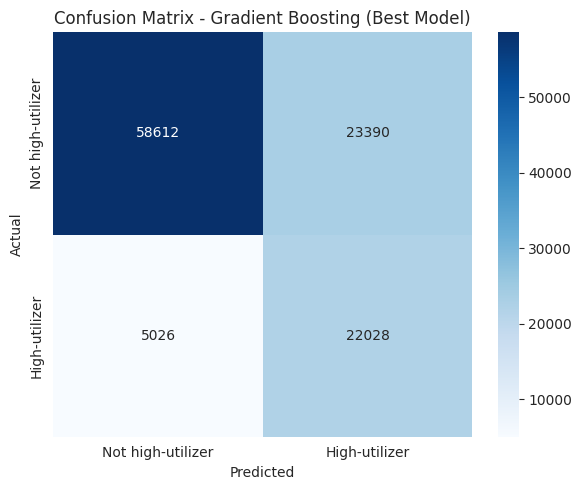

In [35]:
cm = confusion_matrix(y_test, results[best_model_name]['preds'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not high-utilizer','High-utilizer'],
            yticklabels=['Not high-utilizer','High-utilizer'])
plt.title(f'Confusion Matrix - {best_model_name} (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_13_confusion_matrix.png'), dpi=150)
plt.show()

### Evaluation Plot 14: Feature importance - best model (selected above)

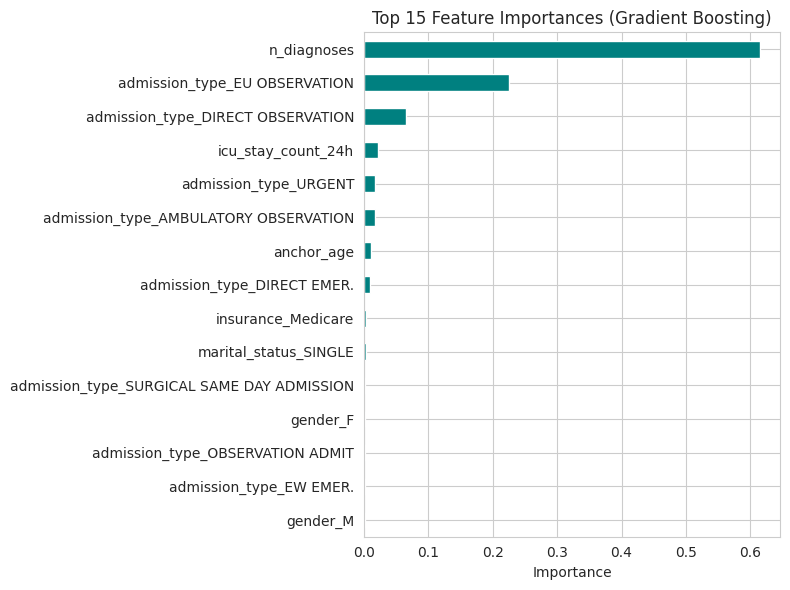

In [36]:
best_pipe_for_importance = trained_pipes[best_model_name]
model_obj = best_pipe_for_importance.named_steps['model']
feat_names = numeric_cols + list(
    best_pipe_for_importance.named_steps['prep']
    .named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
)

if hasattr(model_obj, 'feature_importances_'):
    # Tree-based models: Decision Tree, Random Forest, Gradient Boosting
    importances = pd.Series(model_obj.feature_importances_, index=feat_names)
    top_feats = importances.sort_values(ascending=False).head(15)
    xlabel = 'Importance'
    title = f'Top 15 Feature Importances ({best_model_name})'
elif hasattr(model_obj, 'coef_'):
    # Linear models: Logistic Regression - sign matters (log-odds direction)
    coefs = pd.Series(model_obj.coef_[0], index=feat_names)
    top_feats = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)
    xlabel = 'Coefficient (log-odds; sign shows direction)'
    title = f'Top 15 Feature Coefficients ({best_model_name})'
else:
    # KNN / Naive Bayes have no direct feature ranking - fall back to Random Forest
    # purely for interpretability, and say so explicitly
    print(f'{best_model_name} has no built-in feature ranking (instance-based/probabilistic '
          f'model). Showing Random Forest feature importances instead, for interpretability only.')
    fallback_pipe = trained_pipes['Random Forest']
    importances = pd.Series(fallback_pipe.named_steps['model'].feature_importances_, index=feat_names)
    top_feats = importances.sort_values(ascending=False).head(15)
    xlabel = 'Importance'
    title = 'Top 15 Feature Importances (Random Forest - interpretability fallback)'

top_feats.to_csv(os.path.join(OUT_DIR, 'feature_importance.csv'))

plt.figure(figsize=(8,6))
top_feats.iloc[::-1].plot(kind='barh', color='teal')
plt.title(title)
plt.xlabel(xlabel)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_14_feature_importance.png'), dpi=150)
plt.show()

## Step 8.5: Patient-Level Risk Output (the actual business deliverable)
AUROC and precision/recall describe how good the model is overall - but a care management team can't act on a summary metric. They need a ranked list of **specific patients** to prioritize for outreach. This is that list, generated using whichever model was selected as best in Step 8.6 above, not a fixed choice.

In [37]:
# Score every patient using the BEST model selected above (not hardcoded)
best_pipe = trained_pipes[best_model_name]
test_probabilities = best_pipe.predict_proba(X_test)[:, 1]
test_predictions = best_pipe.predict(X_test)

print(f'Generating patient risk list using: {best_model_name}')

patient_risk_table = cohort.loc[X_test.index, ['subject_id', 'hadm_id']].copy()
patient_risk_table['predicted_probability'] = test_probabilities
patient_risk_table['flagged_high_risk'] = test_predictions
patient_risk_table['flagged_high_risk'] = patient_risk_table['flagged_high_risk'].map({1: 'Yes', 0: 'No'})
patient_risk_table['actual_outcome'] = y_test.values
patient_risk_table['actual_outcome'] = patient_risk_table['actual_outcome'].map({1: 'High-utilizer', 0: 'Not high-utilizer'})

patient_risk_table = patient_risk_table.sort_values('predicted_probability', ascending=False).reset_index(drop=True)

patient_risk_table.to_csv(os.path.join(OUT_DIR, 'patient_risk_scores.csv'), index=False)
print(f'Saved patient_risk_scores.csv ({len(patient_risk_table)} patients, ranked by risk)')
print('\nTop 20 highest-risk patients (who a care team would call first):')
patient_risk_table.head(20)

Generating patient risk list using: Gradient Boosting
Saved patient_risk_scores.csv (109056 patients, ranked by risk)

Top 20 highest-risk patients (who a care team would call first):


,subject_id,hadm_id,predicted_probability,flagged_high_risk,actual_outcome
0,17295976,29633749,0.991492,Yes,High-utilizer
1,19732617,22795852,0.990765,Yes,High-utilizer
2,16686831,29363597,0.990751,Yes,High-utilizer
3,13382160,24509820,0.990622,Yes,High-utilizer
4,12773650,26188836,0.990422,Yes,High-utilizer
5,12651793,24847085,0.990040,Yes,High-utilizer
6,19459778,25884565,0.989847,Yes,High-utilizer
7,14232172,23711326,0.989628,Yes,High-utilizer
8,10613163,23598136,0.989602,Yes,High-utilizer
9,10169328,24837691,0.989554,Yes,High-utilizer


## Step 8.55: Fairness Audit
`insurance` and `marital_status` are used as predictors, and `insurance` shows non-trivial SHAP importance. Since this model helps decide who gets extra care-management attention, this checks whether the model's false-negative rate (missed high-risk patients) is noticeably uneven across insurance categories - a signal of potential bias worth naming in the report even if not fully resolved here.

In [38]:
test_df_fair = X_test.copy()
test_df_fair['y_true'] = y_test.values
test_df_fair['y_pred'] = results[best_model_name]['preds']

fairness_rows = []
for category, group in test_df_fair.groupby('insurance'):
    if len(group) < 20:
        continue
    fn = ((group['y_true'] == 1) & (group['y_pred'] == 0)).sum()
    actual_pos = (group['y_true'] == 1).sum()
    fnr = fn / actual_pos if actual_pos else float('nan')
    fairness_rows.append({'insurance': category, 'n': len(group),
                           'actual_high_risk': actual_pos, 'false_negative_rate': fnr})
    print(f"{category:20s} n={len(group):5d}  actual high-risk={actual_pos:4d}  FNR={fnr:.3f}")

fairness_df = pd.DataFrame(fairness_rows).sort_values('false_negative_rate', ascending=False)
fairness_df.to_csv(os.path.join(OUT_DIR, 'fairness_audit_by_insurance.csv'), index=False)
print()
print('Saved fairness_audit_by_insurance.csv')
print('A noticeably higher false-negative rate for any one category means the model is')
print('quietly missing more true high-risk patients in that group - worth naming in the report')
print('even if not fully resolved (Section 12.1 / future work).')

Medicaid             n=20441  actual high-risk=4537  FNR=0.182
Medicare             n=49471  actual high-risk=14796  FNR=0.147
No charge            n=  103  actual high-risk=  11  FNR=0.727
Other                n= 2724  actual high-risk= 650  FNR=0.188
Private              n=34438  actual high-risk=6768  FNR=0.265

Saved fairness_audit_by_insurance.csv
A noticeably higher false-negative rate for any one category means the model is
quietly missing more true high-risk patients in that group - worth naming in the report
even if not fully resolved (Section 12.1 / future work).


### Plot 15: Distribution of predicted risk scores
Shows how spread out the model's confidence is across patients - a useful sanity check and a good visual for your report.

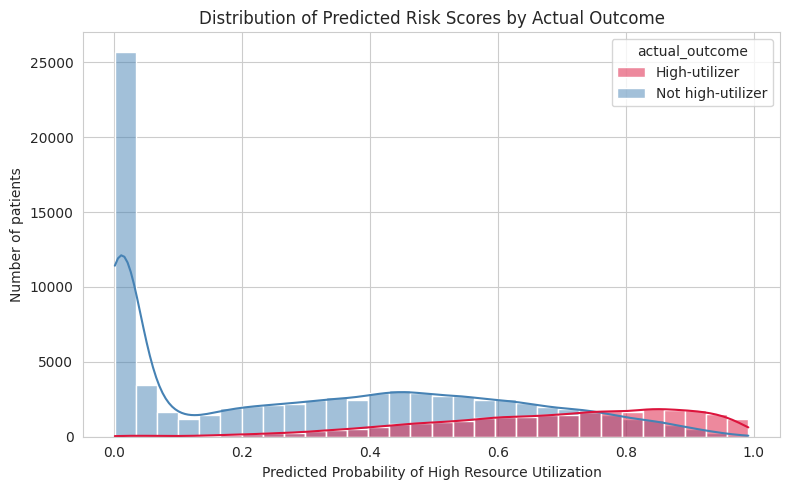

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(patient_risk_table, x='predicted_probability', hue='actual_outcome',
             bins=30, kde=True, palette={'High-utilizer':'crimson','Not high-utilizer':'steelblue'})
plt.title('Distribution of Predicted Risk Scores by Actual Outcome')
plt.xlabel('Predicted Probability of High Resource Utilization')
plt.ylabel('Number of patients')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_15_risk_score_distribution.png'), dpi=150)
plt.show()

## Step 8.9: SHAP Values (Master's-level interpretability)
Feature importance (used earlier) only shows overall magnitude - it can't show whether a feature pushes predictions UP or DOWN, or how that varies per patient. SHAP (SHapley Additive exPlanations) values show, for every individual prediction, exactly how much each feature contributed and in which direction. This works for any of the 6 model types, with the explainer chosen automatically based on model family.

In [40]:
import shap

def extract_shap_matrix(sv):
    """Normalize SHAP output across explainer types to a plain
    (n_samples, n_features) array of contributions toward the positive class."""
    arr = sv.values if hasattr(sv, 'values') else np.array(sv)
    if isinstance(sv, list):
        arr = np.array(sv[1])
    if arr.ndim == 3:
        arr = arr[:, :, 1]
    return arr

shap_pipe = trained_pipes[best_model_name]
shap_prep = shap_pipe.named_steps['prep']
shap_model = shap_pipe.named_steps['model']

X_train_transformed = shap_prep.transform(X_train)
X_test_transformed = shap_prep.transform(X_test)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

shap_feat_names = numeric_cols + list(
    shap_prep.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
)

n_sample = min(200, len(X_test_transformed))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test_transformed), size=n_sample, replace=False)
X_shap_sample = X_test_transformed[sample_idx]

print(f'Computing SHAP values for {best_model_name} on {n_sample} sampled test rows...')

if hasattr(shap_model, 'feature_importances_'):
    explainer = shap.TreeExplainer(shap_model)
    sv = explainer.shap_values(X_shap_sample)
elif hasattr(shap_model, 'coef_'):
    background = shap.sample(X_train_transformed, min(100, len(X_train_transformed)), random_state=RANDOM_STATE)
    explainer = shap.LinearExplainer(shap_model, background)
    sv = explainer.shap_values(X_shap_sample)
else:
    print('Non-tree, non-linear model - using model-agnostic explainer (slower).')
    background = shap.sample(X_train_transformed, min(50, len(X_train_transformed)), random_state=RANDOM_STATE)
    explainer = shap.Explainer(shap_model.predict_proba, background, feature_names=shap_feat_names)
    sv = explainer(X_shap_sample[:min(100, n_sample)])
    X_shap_sample = X_shap_sample[:min(100, n_sample)]

shap_matrix = extract_shap_matrix(sv)
print(f'SHAP matrix shape: {shap_matrix.shape} (samples x features)')

Computing SHAP values for Gradient Boosting on 200 sampled test rows...
SHAP matrix shape: (200, 23) (samples x features)


### Plot 18: SHAP summary plot
Each dot is one patient. Position on the x-axis shows whether that feature pushed the prediction toward high-risk (right) or low-risk (left) for that specific patient - color shows whether the feature's value was high or low.

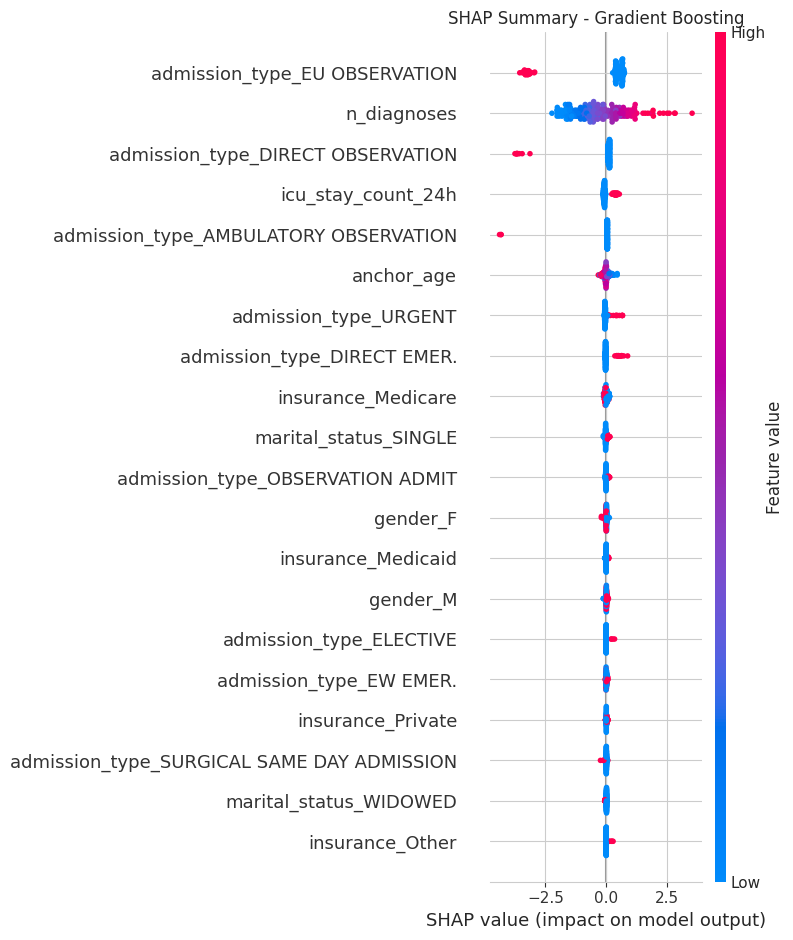

In [41]:
plt.figure(figsize=(9,7))
shap.summary_plot(shap_matrix, X_shap_sample, feature_names=shap_feat_names, show=False)
plt.title(f'SHAP Summary - {best_model_name}')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_18_shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

### Plot 19: SHAP mean absolute importance (bar form)
Simpler companion view - average magnitude of each feature's SHAP contribution.

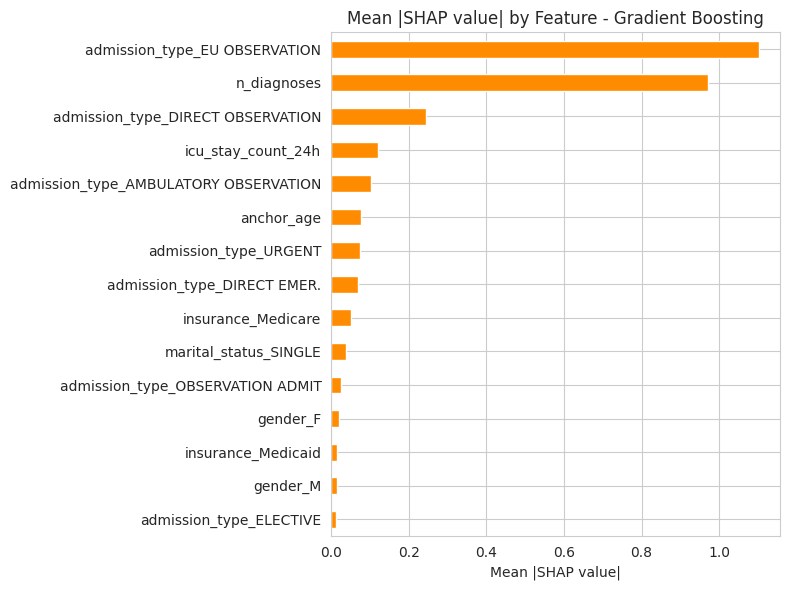

In [42]:
mean_abs_shap = pd.Series(np.abs(shap_matrix).mean(axis=0), index=shap_feat_names)
top_shap = mean_abs_shap.sort_values(ascending=False).head(15)
top_shap.to_csv(os.path.join(OUT_DIR, 'shap_importance.csv'))

plt.figure(figsize=(8,6))
top_shap.iloc[::-1].plot(kind='barh', color='darkorange')
plt.title(f'Mean |SHAP value| by Feature - {best_model_name}')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_19_shap_importance.png'), dpi=150)
plt.show()

## Step 8.10: Statistical Significance Testing
Reporting "Model A had AUROC 0.72, Model B had 0.68" isn't enough at Master's level - that gap could easily be noise. This uses bootstrap resampling (1000 resamples of the test set) to build a 95% confidence interval for each model's AUROC, and directly tests whether the top 2 models are significantly different.

In [43]:
from sklearn.utils import resample

N_BOOTSTRAPS = 1000
bootstrap_results = {}

print(f'Running {N_BOOTSTRAPS} bootstrap resamples per model...')

for name, r in results.items():
    boot_aucs = []
    y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
    proba_arr = r['proba']
    n = len(y_test_arr)
    rng = np.random.RandomState(RANDOM_STATE)
    for i in range(N_BOOTSTRAPS):
        idx = rng.randint(0, n, n)
        y_boot = y_test_arr[idx]
        if len(np.unique(y_boot)) < 2:
            continue
        boot_aucs.append(roc_auc_score(y_boot, proba_arr[idx]))
    boot_aucs = np.array(boot_aucs)
    ci_lower, ci_upper = np.percentile(boot_aucs, [2.5, 97.5])
    bootstrap_results[name] = {'mean': boot_aucs.mean(), 'ci_lower': ci_lower,
                               'ci_upper': ci_upper, 'boot_aucs': boot_aucs}
    print(f'{name}: AUROC = {boot_aucs.mean():.3f}, 95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]')

Running 1000 bootstrap resamples per model...
Logistic Regression: AUROC = 0.846, 95% CI = [0.844, 0.849]
Decision Tree: AUROC = 0.843, 95% CI = [0.840, 0.845]
Random Forest: AUROC = 0.846, 95% CI = [0.843, 0.848]
Gradient Boosting: AUROC = 0.852, 95% CI = [0.850, 0.854]
K-Nearest Neighbors: AUROC = 0.828, 95% CI = [0.826, 0.831]
Naive Bayes: AUROC = 0.808, 95% CI = [0.806, 0.811]
XGBoost: AUROC = 0.850, 95% CI = [0.847, 0.852]


### Plot 20: AUROC with 95% confidence intervals

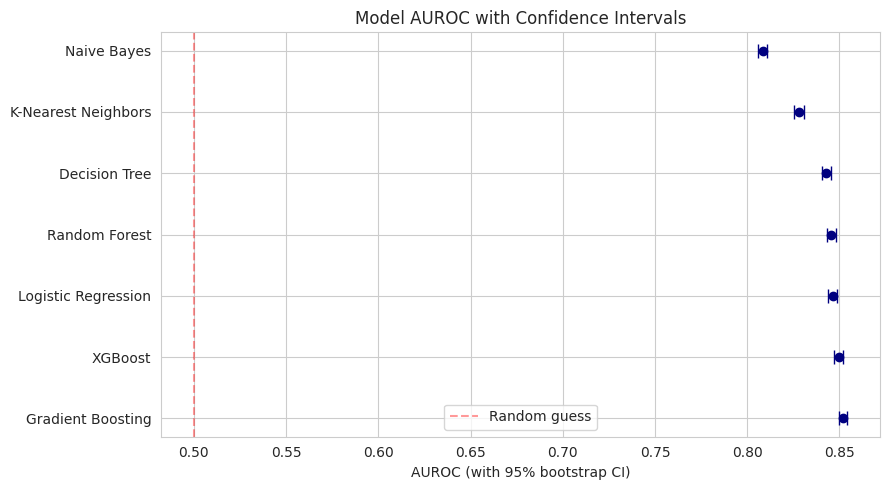

In [44]:
plt.figure(figsize=(9,5))
names_sorted = sorted(bootstrap_results.keys(), key=lambda n: bootstrap_results[n]['mean'], reverse=True)
means = [bootstrap_results[n]['mean'] for n in names_sorted]
lowers = [bootstrap_results[n]['mean'] - bootstrap_results[n]['ci_lower'] for n in names_sorted]
uppers = [bootstrap_results[n]['ci_upper'] - bootstrap_results[n]['mean'] for n in names_sorted]

plt.errorbar(means, range(len(names_sorted)), xerr=[lowers, uppers], fmt='o', capsize=5, color='navy')
plt.yticks(range(len(names_sorted)), names_sorted)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Random guess')
plt.xlabel('AUROC (with 95% bootstrap CI)')
plt.title('Model AUROC with Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eval_20_auroc_confidence_intervals.png'), dpi=150)
plt.show()

### Is the top model actually significantly better than the runner-up?

In [46]:
top_two = summary_df.index[:2].tolist()
name_a, name_b = top_two[0], top_two[1]

n_common = min(len(bootstrap_results[name_a]['boot_aucs']), len(bootstrap_results[name_b]['boot_aucs']))
auc_diff = bootstrap_results[name_a]['boot_aucs'][:n_common] - bootstrap_results[name_b]['boot_aucs'][:n_common]
diff_ci_lower, diff_ci_upper = np.percentile(auc_diff, [2.5, 97.5])

print(f'Comparing top 2 models: {name_a} vs {name_b}')
print(f'AUROC difference: {auc_diff.mean():+.3f}, 95% CI = [{diff_ci_lower:+.3f}, {diff_ci_upper:+.3f}]')

if diff_ci_lower <= 0 <= diff_ci_upper:
    print(f'\nCI includes zero - {name_a} and {name_b} are basically tied, not '
          f'meaningfully different. Worth saying so instead of picking a "winner".')
else:
    print(f'\nCI excludes zero - {name_a} is actually better than {name_b}, not just noise.')

Comparing top 2 models: Gradient Boosting vs XGBoost
AUROC difference: +0.002, 95% CI = [+0.002, +0.003]

CI excludes zero - Gradient Boosting is actually better than XGBoost, not just noise.


## Step 9: Confirm all outputs saved

In [47]:
print(sorted(os.listdir(OUT_DIR)))

['calibration_plot.png', 'calibration_summary_all_models.csv', 'cohort_with_features.csv', 'eda_01_age_distribution.png', 'eda_02_gender_distribution.png', 'eda_03_los_distribution.png', 'eda_04_los_by_admission_type.png', 'eda_05_admission_type_counts.png', 'eda_06_insurance_counts.png', 'eda_07_diagnoses_distribution.png', 'eda_08_icu_stay_counts.png', 'eda_09_correlation_heatmap.png', 'eda_10_marital_status_counts.png', 'eda_11_class_balance.png', 'eval_12_roc_curve.png', 'eval_13_confusion_matrix.png', 'eval_14_feature_importance.png', 'eval_15_risk_score_distribution.png', 'eval_16_model_comparison.png', 'eval_17_train_vs_test.png', 'eval_18_shap_summary.png', 'eval_19_shap_importance.png', 'eval_20_auroc_confidence_intervals.png', 'fairness_audit_by_insurance.csv', 'feature_importance.csv', 'model_comparison_summary.csv', 'patient_risk_scores.csv', 'shap_importance.csv', 'test_set.csv', 'train_set.csv', 'train_vs_test_comparison.csv', 'tuned_model_comparison.csv']


## Step 10: Download everything

In [48]:
!zip -r outputs.zip outputs_classification
from google.colab import files
files.download('outputs.zip')

  adding: outputs_classification/ (stored 0%)
  adding: outputs_classification/test_set.csv (deflated 90%)
  adding: outputs_classification/eda_06_insurance_counts.png (deflated 26%)
  adding: outputs_classification/eda_03_los_distribution.png (deflated 13%)
  adding: outputs_classification/eval_14_feature_importance.png (deflated 20%)
  adding: outputs_classification/eda_05_admission_type_counts.png (deflated 20%)
  adding: outputs_classification/model_comparison_summary.csv (deflated 40%)
  adding: outputs_classification/eval_20_auroc_confidence_intervals.png (deflated 20%)
  adding: outputs_classification/eda_07_diagnoses_distribution.png (deflated 12%)
  adding: outputs_classification/eval_18_shap_summary.png (deflated 12%)
  adding: outputs_classification/eval_13_confusion_matrix.png (deflated 14%)
  adding: outputs_classification/eda_04_los_by_admission_type.png (deflated 15%)
  adding: outputs_classification/eda_10_marital_status_counts.png (deflated 26%)
  adding: outputs_class

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
import glob
import os
from google.colab import files

# Search for the notebook anywhere in your Drive, so you don't need to type the exact path
matches = glob.glob('/content/drive/MyDrive/**/Capstone_final.ipynb', recursive=True)

if not matches:
    print("Could not find Capstone_final.ipynb in your Drive. Check the filename matches exactly.")
else:
    notebook_path = matches[0]
    print(f"Found notebook at: {notebook_path}")

    !jupyter nbconvert --to html "{notebook_path}" --output "/content/capstone_report.html"
    files.download("/content/capstone_report.html")

Found notebook at: /content/drive/MyDrive/Colab Notebooks/Capstone_final.ipynb
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Capstone_final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 20 image(s).
[NbConvertApp] Writing 1745911 bytes to /content/capstone_report.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>